In [1]:
import earthaccess
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from mpl_toolkits.basemap import Basemap
from metpy.units import units
import metpy.calc as mpcalc
from metpy.constants import *
from scipy.optimize import curve_fit
from matplotlib.colors import LogNorm
from tqdm import tqdm
import glob 
import re
from datetime import datetime
from tools import time_from_attr, open_L2_CLOUD_GPC, plot_hist

# import warnings
# warnings.filterwarnings("ignore")

## Plot 1: OCI vertical histogram of LWP vs CDNC

In [2]:
def ds_slicing(ds, bounding_box = (-110,-35,-70,-10)):
    datetime = ds.attrs["time_coverage_start"].replace("Z", "")
    time = np.datetime64(datetime, "ns")
    ds = ds.assign_coords(time=[time])
    return (ds.sel(lat=slice(bounding_box[3], bounding_box[1]), lon=slice(bounding_box[0], bounding_box[2])))

In [3]:
# Define your date range
start_date = datetime(2025, 7, 1)
end_date   = datetime(2025, 7, 31)

files = glob.glob("/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_OCI_L3M_CLOUD_v3_1/*.V3_1.*.nc")

# Extract date from filename and filter by range
def extract_date(f):
    match = re.search(r"(\d{8})", f)
    if match:
        return datetime.strptime(match.group(1), "%Y%m%d")
    return None

path = [f for f in files if extract_date(f) and start_date <= extract_date(f) <= end_date]

In [4]:
dataset = xr.open_mfdataset(path, preprocess=ds_slicing)
# dataset

In [5]:
def Nd_adiabatic_model(tau, re, Cw=0.0020, fad=0.7, k=0.8, Qe = 2.0):
    """
    tau: cloud optical thickness (τ) [unitless]
    re: cloud effective radius [µm]
    fad : adiabaticity of cloud [unitless]
    Cw:   lapse rate of water content [g/m^4]
    k:    disperson const rv^3 = k * re^3
    Qe:  extinction efficiency [unitless]

    """
    C = np.sqrt(5)/(2.0*np.pi*k)
    re_m = re*1e-6                     # change unit of re from um to m
    rho  = 1e6                         # density of water [g/m^3]
    CDNC = C * np.sqrt(fad*Cw*tau/Qe/rho/(re_m**5)) *1e-6
    return CDNC

In [6]:
Nd = Nd_adiabatic_model(dataset.cth_cot, dataset.cer_21)

In [7]:
# precalculate DASK arrays for faster computation/plotting
Nd = Nd.compute()
lwp = dataset.cwp_21.data.compute()

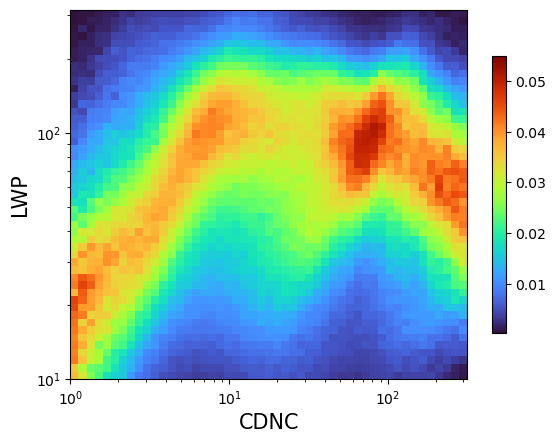

In [8]:
plot_hist(Nd.data.flatten(), lwp.flatten())      # Density plot

## Plot 2: HARP2 vertical histogram of LWP vs CDNC

In [11]:
auth = earthaccess.login(persist=True)

In [12]:
bbox = (-110,-35,-70,-10)
results = earthaccess.search_data(
    short_name="PACE_HARP2_L2_CLOUD_GPC", 
    bounding_box=bbox,
)
print(len(results))

3808


In [35]:
files = earthaccess.download(results, "/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_HARP2_L2_CLOUD_GPC_bbox")

In [2]:
start_date = datetime(2025, 7, 1)
end_date   = datetime(2025, 7, 31)

files = glob.glob("/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_HARP2_L2_CLOUD_GPC_bbox/*.V3_0.nc")

# Extract date from filename and filter by range
def extract_date(f):
    match = re.search(r"(\d{8})", f)
    if match:
        return datetime.strptime(match.group(1), "%Y%m%d")
    return None

paths = [f for f in files if extract_date(f) and start_date <= extract_date(f) <= end_date]
print(len(paths))

256


In [12]:
er = []
ev = []
cdnc = []
lwp = []
lat = []
lon = []
count = 0
for p in paths:

    try: 
        ds = open_L2_CLOUD_GPC(p, bbox)
        mask = (
            ~np.isnan(ds.cloud_bow_droplet_effective_radius.data.flatten()) & 
            ~np.isnan(ds.cloud_bow_droplet_effective_variance.data.flatten()) & 
            ~np.isnan(ds.cloud_bow_droplet_number_concentration_adiabatic.data.flatten()) & 
            ~np.isnan(ds.cloud_bow_liquid_water_path.data.flatten())
        )
        
        er = np.concatenate((er, ds.cloud_bow_droplet_effective_radius.data.flatten()[mask]))
        ev = np.concatenate((ev, ds.cloud_bow_droplet_effective_variance.data.flatten()[mask]))
        cdnc = np.concatenate((cdnc, ds.cloud_bow_droplet_number_concentration_adiabatic.data.flatten()[mask]))
        lwp = np.concatenate((lwp, ds.cloud_bow_liquid_water_path.data.flatten()[mask]))
        del(ds)
        
    except:
        print('I had an error', count)
    count += 1

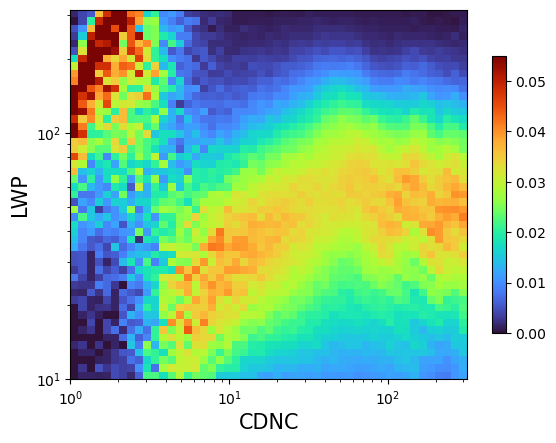

In [13]:
plot_hist(cdnc, lwp)